# Phase 5 — Leakage-safe ML baseline

This notebook is presentation evidence for a reproducible classical baseline. It classifies the three approved **synthetic** Finnish learner-error labels from `incorrect_sentence`; it is not a general Finnish grammar checker. All production logic lives in `app.services.ml_training`.

## Prediction task and limitations

Input: one synthetic incorrect sentence. Target: `AGREEMENT`, `CASE_ERROR`, or `VERB_CONJUGATION`. Synthetic data gives exact labels and corrections but can contain generator-specific shortcuts and does not reproduce the ambiguity or distribution of real learner writing.

In [1]:
from pathlib import Path
import json, sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from app.services.ml_training import APPROVED_LABELS, MLConfig, run_phase5
ROOT

mkdir -p failed for path C:\Users\leanh\AppData\Local\matplotlib: [WinError 5] Access is denied: 'C:\\Users\\leanh\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\leanh\AppData\Local\Temp\matplotlib-ajby_xgm because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


WindowsPath('C:/Users/leanh/OneDrive/Desktop/code/finnish_learning_assistant')

## Reproduce the complete experiment

The service verifies the Phase 4 input hash, creates the fixed grouped split, fits normalization/TF-IDF/Logistic Regression on **training text only**, evaluates validation and then the untouched test partition, and writes the split, model, predictions, and metadata artifacts.

In [2]:
metadata = run_phase5(ROOT, MLConfig())
split_manifest = json.loads((ROOT / 'data/evaluation/ml_split_manifest_v1.json').read_text(encoding='utf-8'))
print('Labels:', ', '.join(metadata['labels']))
print('Records:', metadata['record_counts'])
print('Vocabulary size:', metadata['feature_configuration']['vocabulary_size'])

Labels: AGREEMENT, CASE_ERROR, VERB_CONJUGATION
Records: {'train': 2101, 'validation': 450, 'test': 449}
Vocabulary size: 31413


## Dataset distribution and grouped split

`StratifiedGroupKFold` uses 20 deterministic folds (seed 42), stratified approximately by `error_type|source_dataset`. Fourteen folds form training, three validation, and three test. Group isolation has priority over exact percentages: every variant with the same Phase 3 `leakage_group_id` stays in one partition.

In [3]:
split_table = pd.DataFrame({
    name: {
        'records': item['records'],
        'proportion': item['proportion'],
        'groups': item['leakage_groups'],
        **item['class_distribution'],
    }
    for name, item in split_manifest['splits'].items()
}).T
display(split_table)
leakage = split_manifest['quality_checks']['leakage_group_isolation']
print('Leakage check passed:', leakage['passed'])
print('Pairwise group intersections:', leakage['intersection_counts'])
assert leakage['passed'] and all(v == 0 for v in leakage['intersection_counts'].values())

,records,proportion,groups,AGREEMENT,CASE_ERROR,VERB_CONJUGATION
train,2101.0,0.700333,1968.0,701.0,700.0,700.0
validation,450.0,0.150000,423.0,150.0,150.0,150.0
test,449.0,0.149667,422.0,149.0,150.0,150.0


Leakage check passed: True
Pairwise group intersections: {'train_validation': 0, 'train_test': 0, 'validation_test': 0}


## Feature and model rationale

Finnish expresses much grammar in word endings, so character-within-word TF-IDF n-grams (3–5 characters) are a compact, interpretable baseline. The feature view applies NFC and removes formatting-only whitespace; stored sentences remain unchanged. Logistic Regression is reproducible, probabilistic, fast, and exposes class weights for interpretation. No transformer or hyperparameter sweep is used.

In [4]:
display(pd.Series(metadata['feature_configuration'], name='feature configuration').to_frame())
display(pd.Series(metadata['classifier_configuration'], name='classifier configuration').to_frame())
display(pd.Series(metadata['runtime_versions'], name='runtime versions').to_frame())
print('Train-only fit:', metadata['quality_checks']['vectorizer_fit_on_training_only'])
print('Classifier converged:', metadata['quality_checks']['classifier_converged'])

,feature configuration
normalization,NFC; collapse whitespace; remove formatting-on...
vectorizer,TfidfVectorizer
analyzer,char_wb
ngram_range,"[3, 5]"
vocabulary_size,31413
fit_scope,training split only


,classifier configuration
type,LogisticRegression
C,1.0
solver,lbfgs
max_iter,2000
class_weight,None
random_state,42
iterations_by_class,[31]


,runtime versions
python,3.12.14
numpy,2.5.3
scikit_learn,1.9.0
joblib,1.6.0


Train-only fit: True
Classifier converged: True


## Train, validation, and final test metrics

Accuracy and macro precision/recall/F1 are reported for all partitions. Macro F1 gives every class equal importance. `log_loss` is calculated from post-fit class probabilities; it is an evaluation metric, not a neural-network loss curve. The configuration was fixed before the one final test evaluation.

In [5]:
summary_metrics = pd.DataFrame({
    split: {key: values[key] for key in ('accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'log_loss')}
    for split, values in metadata['metrics'].items()
}).T
display(summary_metrics.style.format('{:.4f}'))
per_class = pd.concat({
    split: pd.DataFrame(values['per_class']).T
    for split, values in metadata['metrics'].items()
})
display(per_class.style.format({'precision': '{:.4f}', 'recall': '{:.4f}', 'f1': '{:.4f}', 'support': '{:.0f}'}))

,accuracy,macro_precision,macro_recall,macro_f1,log_loss
train,0.9334,0.9330,0.9334,0.9331,0.5090
validation,0.6911,0.6856,0.6911,0.6873,0.7055
test,0.7105,0.7084,0.7102,0.7092,0.7035


## Confusion matrix

The test confusion matrix shows which labels remain difficult. Counts—not normalized percentages—make the evaluation population explicit.

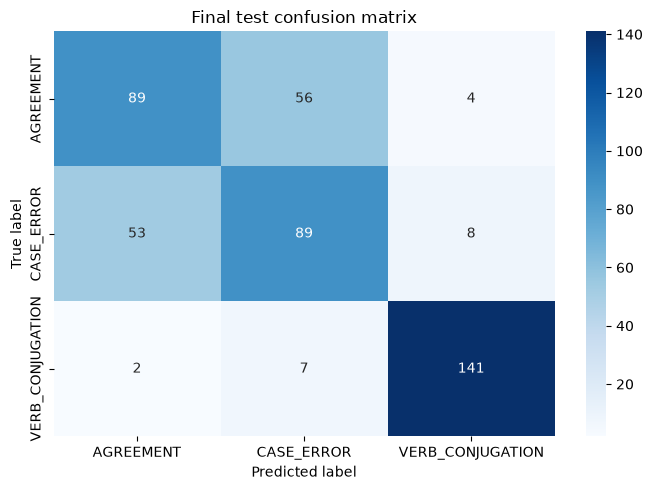

In [6]:
cm = metadata['metrics']['test']['confusion_matrix']
plt.figure(figsize=(7, 5))
sns.heatmap(cm['values'], annot=True, fmt='d', cmap='Blues', xticklabels=cm['labels'], yticklabels=cm['labels'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Final test confusion matrix')
plt.tight_layout()
plt.show()

## Feature interpretation and shortcut risk

High-weight character fragments can reflect Finnish endings, pronouns, and the generator's replacement inventory. They are evidence about classifier behavior, not proof of grammar understanding. We therefore compare with a source-only majority heuristic, report results per treebank, and examine the train–test gap.

In [7]:
top_features = pd.DataFrame([
    {'label': label, **item}
    for label, items in metadata['interpretation']['top_positive_features'].items()
    for item in items[:10]
])
top_features['rank'] = top_features.groupby('label').cumcount() + 1
display(top_features.pivot(index='rank', columns='label', values='feature'))
shortcut = metadata['shortcut_checks']
print('Training majority baseline:', round(shortcut['training_global_majority_accuracy'], 4))
print('Validation source-only baseline:', round(shortcut['validation_source_only_majority']['accuracy'], 4))
print('Test source-only baseline:', round(shortcut['test_source_only_majority']['accuracy'], 4))
print('Train–test macro-F1 gap:', round(shortcut['train_test_macro_f1_gap'], 4))
display(pd.DataFrame({source: {k: v[k] for k in ('accuracy', 'macro_f1')} for source, v in shortcut['test_metrics_by_source'].items()}).T)
length_audit = shortcut['test_metrics_by_train_length_quartile']
print('Train-derived character-length thresholds:', length_audit['train_character_length_quartile_thresholds'])
display(pd.DataFrame(length_audit['evaluation']).T)

label,AGREEMENT,CASE_ERROR,VERB_CONJUGATION
rank,,,
1,iset,ine,hän
2,iset,nen,hän
3,set,inen,hän
4,et,inen,hän
5,set,nen,hä
6,ien,isen,än
7,ten,oma,inä
8,hyvät,isen,inä
9,omi,vää,nä


Training majority baseline: 0.3337
Validation source-only baseline: 0.44
Test source-only baseline: 0.441
Train–test macro-F1 gap: 0.2239


,accuracy,macro_f1
UD_Finnish-FTB,0.779412,0.729758
UD_Finnish-TDT,0.653061,0.691651


Train-derived character-length thresholds: [53.0, 87.0, 125.0]


,records,class_distribution,accuracy,macro_f1
Q1_shortest,120,"{'AGREEMENT': 20, 'CASE_ERROR': 14, 'VERB_CONJ...",0.883333,0.7351
Q2,111,"{'AGREEMENT': 44, 'CASE_ERROR': 37, 'VERB_CONJ...",0.72973,0.740864
Q3,101,"{'AGREEMENT': 36, 'CASE_ERROR': 46, 'VERB_CONJ...",0.584158,0.611863
Q4_longest,117,"{'AGREEMENT': 49, 'CASE_ERROR': 53, 'VERB_CONJ...",0.623932,0.656212


## Misclassification and high-confidence review

The most confident errors reveal systematic confusion; high-confidence correct cases reveal what the model finds easy. Confidence is a model probability, not a linguistic-validity score.

In [8]:
errors = pd.DataFrame(metadata['interpretation']['misclassified_test_examples'])
display(errors[['incorrect_sentence', 'true_label', 'predicted_label', 'confidence']].head(12))
high_confidence = pd.DataFrame([
    row for rows in metadata['interpretation']['high_confidence_correct_test_examples'].values() for row in rows
])
display(high_confidence[['incorrect_sentence', 'true_label', 'confidence']].head(12))

,incorrect_sentence,true_label,predicted_label,confidence
0,Kielellä on rikkaat uskonnollinen ja historial...,AGREEMENT,CASE_ERROR,0.713719
1,Tutkijoiden tavoitteena on tunnistaa ne neurol...,CASE_ERROR,AGREEMENT,0.687821
2,"Miekkaa hän ei juurikaan osannut käyttää, hän ...",AGREEMENT,VERB_CONJUGATION,0.662520
3,"Uskoin, että kun leppäkerttu laskeutui kädelle...",CASE_ERROR,VERB_CONJUGATION,0.630621
4,Suomessa ei murehdita myöskään yhteystietojen ...,CASE_ERROR,AGREEMENT,0.622028
5,"Kaunokirjallisuutta , erilaisia tietoa , viihd...",AGREEMENT,CASE_ERROR,0.613619
6,"No se siitä työkalusta , kyllähän Aamulehdessä...",CASE_ERROR,VERB_CONJUGATION,0.611095
7,Kuka itseään kunnioittava kirjailija enää keht...,AGREEMENT,CASE_ERROR,0.604880
8,"Haluaisin huomauttaa, että 70 kongressin jäsen...",CASE_ERROR,AGREEMENT,0.599041
9,"Nilkka nyrjähtelee helposti uudestaan, on liik...",AGREEMENT,CASE_ERROR,0.597235


,incorrect_sentence,true_label,confidence
0,". – Arvoisa puhemies, arvoisa komission jäsen,...",AGREEMENT,0.749448
1,Tällaisissa tapauksissa tehdään oikaisuja tuon...,AGREEMENT,0.735584
2,Näiden erojen on syytä saada kansainväliset yh...,AGREEMENT,0.699307
3,Dosentti Marko Lehti toi keskustelussa esiin E...,AGREEMENT,0.666990
4,pienten ihmisen puolesta taistelleen,AGREEMENT,0.660235
5,Tutkijat Emma Vironmäki ja Leena Jokinen esitt...,CASE_ERROR,0.645050
6,"Siitä tulee normaali käytäntö, ja oleellinen e...",CASE_ERROR,0.641497
7,Toinen teoria nimen alkuperästä perustuu alkup...,CASE_ERROR,0.638558
8,- Esimerkiksi riidan toinen osapuoli voi väitt...,CASE_ERROR,0.629621
9,Tukholman Oopperakellarin barokkityylinen päär...,CASE_ERROR,0.618129


## Conclusions, limitations, and Phase 6 hand-off

Phase 5 provides a saved, complete inference pipeline plus reproducible group-safe evaluation evidence. The test result measures discrimination among three controlled synthetic transformations only. The strong verb result and lower agreement/case results are consistent with overt pronoun and suffix cues; the source-only baseline and per-treebank differences confirm residual shortcut risk. A later phase may consume the saved classifier as one bounded signal, but must not present it as a general grammar authority or retrain/tune it on the test set.

Artifacts: `data/evaluation/{train,validation,test}_v1.jsonl`, `ml_split_manifest_v1.json`, `ml_test_predictions_v1.jsonl`, `models/error_classifier_v1.joblib`, and `models/error_classifier_v1_metadata.json`.